# FactoryMind AI — Anomaly Detection Baseline

This notebook investigates whether classical anomaly detection can identify unusual FD001 engine sensor states and degradation progression. It is a research baseline—not a production detector, alert policy, or probability model.

## 1. Problem Definition

This is an **unsupervised condition-monitoring** problem. The detector learns a representation of normal engine operation and assigns a continuous score to observations that deviate from that reference.

- Supervised failure prediction: sensor state → known failure label.
- RUL regression: sensor trajectory → remaining-life target.
- Anomaly detection: sensor state or recent behavior → unusualness relative to learned normal operation.

Anomaly does not automatically mean failure. It can reflect genuine degradation, unusual but valid operation, noise, or sensor behavior poorly represented by the reference data.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import pearsonr, spearmanr
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
NORMAL_RUL_CUTOFF = 125
TRAIN_PATH = Path("../data/raw/train_FD001.txt")
COLUMNS = (["unit_id", "cycle"] +
           [f"operational_setting_{i}" for i in range(1, 4)] +
           [f"sensor_{i}" for i in range(1, 22)])
EXCLUDED_SENSORS = ["sensor_1", "sensor_5", "sensor_6", "sensor_10", "sensor_16", "sensor_18", "sensor_19"]
SENSOR_FEATURES = [f"sensor_{i}" for i in range(1, 22) if f"sensor_{i}" not in EXCLUDED_SENSORS]
TEMPORAL_BASE = ["sensor_4", "sensor_7", "sensor_11", "sensor_12", "sensor_15", "sensor_21"]
STAGE_ORDER = ["Healthy / early", "Degrading", "Near failure", "Critical late life"]
QUANTILES = [0.95, 0.975, 0.99]
print(f"Retained sensors ({len(SENSOR_FEATURES)}): {SENSOR_FEATURES}")

Retained sensors (14): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


## 2. Load and Validate FD001

The canonical C-MAPSS schema from notebooks 06–10 is reused. Raw RUL is derived only for retrospective subset construction and evaluation; it is explicitly excluded from every predictor matrix.

In [2]:
df = pd.read_csv(TRAIN_PATH, sep=r"\s+", header=None, names=COLUMNS)
final_cycles = df.groupby("unit_id")["cycle"].transform("max")
df["raw_rul"] = final_cycles - df["cycle"]

assert df.shape == (20_631, 27)
assert df["unit_id"].nunique() == 100
assert [c for c in df if c.startswith("operational_setting_")] == COLUMNS[2:5]
assert len([c for c in df if c.startswith("sensor_")]) == 21
assert df.isna().sum().sum() == 0
print(f"Observations: {len(df):,} | Units: {df.unit_id.nunique()} | Cycles: {df.cycle.min()}–{df.cycle.max()}")
display(df.head())

Observations: 20,631 | Units: 100 | Cycles: 1–362


,unit_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,raw_rul
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


## 3. Normal Reference and Unit-Aware Split

FD001 trajectories run to failure, so treating every row as normal would contaminate the reference with degraded states. We provisionally define **normal reference = raw RUL > 125 cycles**, consistent with the early-life region used elsewhere in this project. RUL is used only to select retrospective reference rows—not as a detector input.

This is a development proxy, not an externally verified healthy label. Engines with lifetimes of 125 cycles or less cannot contribute reference rows. Held-out units remain completely unseen during scaling and detector fitting.

In [3]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, heldout_idx = next(splitter.split(df, groups=df["unit_id"]))
train_units = set(df.iloc[train_idx]["unit_id"].unique())
heldout_units = set(df.iloc[heldout_idx]["unit_id"].unique())
train_df = df[df.unit_id.isin(train_units)].copy()
heldout_df = df[df.unit_id.isin(heldout_units)].copy()
normal_train = train_df[train_df.raw_rul > NORMAL_RUL_CUTOFF].copy()

assert train_units.isdisjoint(heldout_units)
assert len(train_units) == 80 and len(heldout_units) == 20
assert set(normal_train.unit_id).issubset(train_units)
assert not set(normal_train.unit_id).intersection(heldout_units)
split_summary = pd.DataFrame({
    "partition": ["Development units", "Held-out units", "Training normal reference", "Held-out evaluation"],
    "units": [len(train_units), len(heldout_units), normal_train.unit_id.nunique(), heldout_df.unit_id.nunique()],
    "observations": [len(train_df), len(heldout_df), len(normal_train), len(heldout_df)],
})
display(split_summary)
print("Zero unit overlap confirmed.")

,partition,units,observations
0,Development units,80,16561
1,Held-out units,20,4070
2,Training normal reference,80,6481
3,Held-out evaluation,20,4070


Zero unit overlap confirmed.


## 4. Feature Contract and Operating Settings

Seven constant or near-constant sensors are excluded. The retained contract contains 14 current sensor values. `unit_id`, `cycle`, RUL fields, final lifetime, labels, and official test information are not predictors.

FD001 represents one operating condition. Its operational settings have negligible useful variation and are omitted from the baseline so unusualness reflects sensor state rather than tiny setting fluctuations. Cycle is also omitted because the goal is condition anomaly detection, not implicit age estimation.

In [4]:
setting_summary = df[[f"operational_setting_{i}" for i in range(1, 4)]].agg(["mean", "std", "min", "max"]).T
display(setting_summary)
for forbidden in ["unit_id", "cycle", "raw_rul", "capped_rul", "RUL", "final_lifetime"]:
    assert forbidden not in SENSOR_FEATURES
assert not set(EXCLUDED_SENSORS).intersection(SENSOR_FEATURES)
print("Predictor contract:", SENSOR_FEATURES)

,mean,std,min,max
operational_setting_1,-0.000009,0.002187,-0.0087,0.0087
operational_setting_2,0.000002,0.000293,-0.0006,0.0006
operational_setting_3,100.000000,0.000000,100.0000,100.0000


Predictor contract: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


## 5. Leakage-Safe Statistical Baseline

A `StandardScaler` is fitted only on normal-reference rows from development units. The baseline score is root-mean-square standardized deviation from that learned center. Larger values always mean more anomalous. It is intentionally simple and interpretable.

In [5]:
state_scaler = StandardScaler().fit(normal_train[SENSOR_FEATURES])
normal_z = state_scaler.transform(normal_train[SENSOR_FEATURES])
heldout_z = state_scaler.transform(heldout_df[SENSOR_FEATURES])
baseline_train_score = np.sqrt(np.mean(normal_z ** 2, axis=1))
heldout_df["Statistical baseline"] = np.sqrt(np.mean(heldout_z ** 2, axis=1))

assert state_scaler.n_samples_seen_ == len(normal_train)
assert SENSOR_FEATURES == list(normal_train[SENSOR_FEATURES].columns)
print("Scaler fit rows:", state_scaler.n_samples_seen_)
display(heldout_df["Statistical baseline"].describe().to_frame().T)

Scaler fit rows: 6481.0


,count,mean,std,min,25%,50%,75%,max
Statistical baseline,4070.0,1.543422,0.917668,0.303414,0.940321,1.222989,1.809629,5.831133


## 6. Isolation Forest — Current Sensor State

Isolation Forest is fitted only on scaled training-normal observations. Scikit-learn's `score_samples` is larger for more normal observations, so the notebook negates it: **anomaly score = −score_samples**, making larger values consistently more anomalous. `contamination` is not used to define an operational threshold.

In [6]:
iforest_raw = IsolationForest(n_estimators=300, max_samples="auto", contamination="auto", random_state=RANDOM_STATE, n_jobs=-1)
iforest_raw.fit(normal_z)
if_raw_train_score = -iforest_raw.score_samples(normal_z)
heldout_df["Isolation Forest — raw"] = -iforest_raw.score_samples(heldout_z)
print("Isolation Forest fitted exclusively on", len(normal_z), "training-normal rows.")

Isolation Forest fitted exclusively on 6481 training-normal rows.


## 7. Controlled Temporal Feature Experiment

The comparison adds only a trailing five-cycle mean and one-cycle delta for six preselected degradation-sensitive sensors. Features are computed within unit, ordered by cycle, and use the current or earlier observations only. No future values are used. Initial deltas are filled with zero; short rolling windows use available history.

In [7]:
def add_backward_features(frame):
    out = frame.sort_values(["unit_id", "cycle"]).copy()
    grouped = out.groupby("unit_id", sort=False)
    for sensor in TEMPORAL_BASE:
        out[f"{sensor}_mean_5"] = grouped[sensor].transform(lambda s: s.rolling(5, min_periods=1).mean())
        out[f"{sensor}_delta_1"] = grouped[sensor].diff().fillna(0.0)
    return out

train_temporal = add_backward_features(train_df)
heldout_temporal = add_backward_features(heldout_df)
TEMPORAL_FEATURES = SENSOR_FEATURES + [f"{s}_{suffix}" for s in TEMPORAL_BASE for suffix in ("mean_5", "delta_1")]
normal_temporal = train_temporal[train_temporal.raw_rul > NORMAL_RUL_CUTOFF]

temporal_scaler = StandardScaler().fit(normal_temporal[TEMPORAL_FEATURES])
temporal_normal_z = temporal_scaler.transform(normal_temporal[TEMPORAL_FEATURES])
temporal_heldout_z = temporal_scaler.transform(heldout_temporal[TEMPORAL_FEATURES])
iforest_temporal = IsolationForest(n_estimators=300, max_samples="auto", contamination="auto", random_state=RANDOM_STATE, n_jobs=-1)
iforest_temporal.fit(temporal_normal_z)
if_temporal_train_score = -iforest_temporal.score_samples(temporal_normal_z)
heldout_df["Isolation Forest — temporal"] = -iforest_temporal.score_samples(temporal_heldout_z)

assert len(normal_temporal) == len(normal_train)
assert temporal_scaler.n_samples_seen_ == len(normal_temporal)
assert not {"raw_rul", "cycle", "unit_id"}.intersection(TEMPORAL_FEATURES)
# Construction uses rolling(current/past) and diff(current-prior), grouped by unit.
for unit, group in heldout_temporal.groupby("unit_id"):
    expected = group["sensor_4"].rolling(5, min_periods=1).mean().to_numpy()
    assert np.allclose(group["sensor_4_mean_5"], expected)
print(f"Temporal contract: {len(TEMPORAL_FEATURES)} features; all backward-looking assertions passed.")

Temporal contract: 26 features; all backward-looking assertions passed.


## 8. Retrospective Evaluation by Lifecycle Stage

Lifecycle stages are evaluation bins only. They are assigned after scores exist and never enter preprocessing or detector fitting. We expect—but do not require—scores to rise as RUL falls.

Statistical baseline                  \
                                  count  median    mean   
lifecycle_stage                                           
Healthy / early                    1550  1.0130  1.0209   
Degrading                          1300  1.1234  1.1572   
Near failure                        600  1.9018  1.9011   
Critical late life                  620  3.2191  3.3133   

                   Isolation Forest — raw                  \
                                    count  median    mean   
lifecycle_stage                                             
Healthy / early                      1550  0.4492  0.4528   
Degrading                            1300  0.4677  0.4739   
Near failure                          600  0.5688  0.5671   
Critical late life                    620  0.6911  0.6814   

                   Isolation Forest — temporal                  
                                         count  median    mean  
lifecycle_stage                                                 
Healthy / early                           1550  0.4489  0.4528  
Degrading                                 1300  0.4625  0.4739  
Near failure                               600  0.5671  0.5605  
Critical late life                         620  0.6525  0.6463

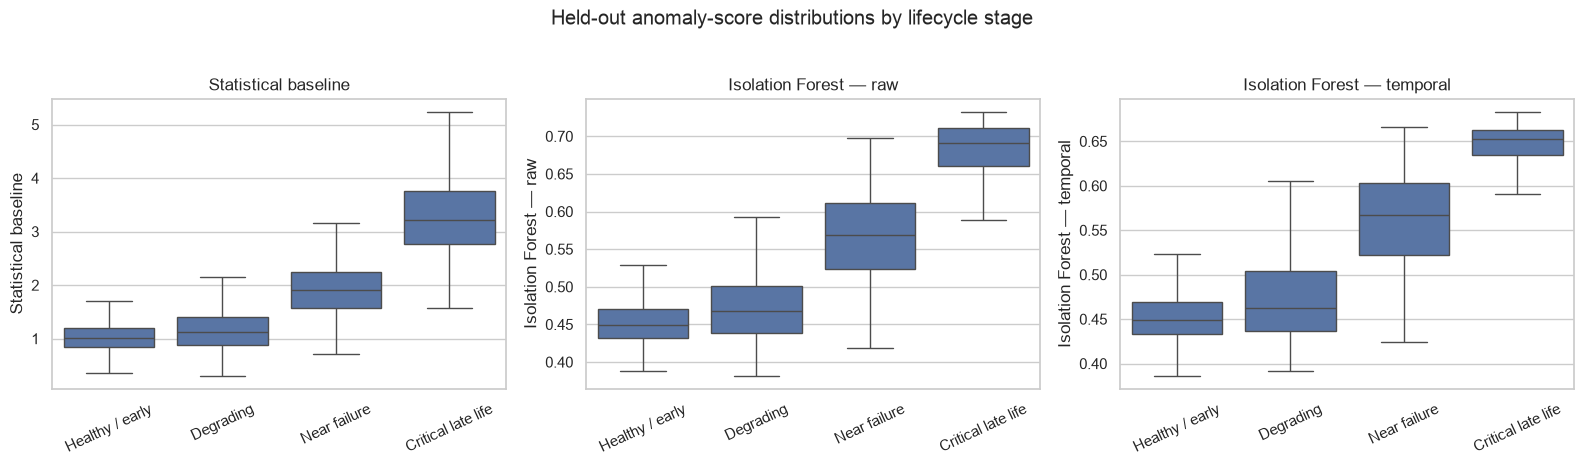

In [8]:
heldout_df["lifecycle_stage"] = pd.cut(
    heldout_df.raw_rul,
    bins=[-1, 30, 60, 125, np.inf],
    labels=["Critical late life", "Near failure", "Degrading", "Healthy / early"],
).astype(pd.CategoricalDtype(STAGE_ORDER, ordered=True))

score_columns = ["Statistical baseline", "Isolation Forest — raw", "Isolation Forest — temporal"]
stage_summary = heldout_df.groupby("lifecycle_stage", observed=True)[score_columns].agg(["count", "median", "mean"])
display(stage_summary.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, score in zip(axes, score_columns):
    sns.boxplot(data=heldout_df, x="lifecycle_stage", y=score, order=STAGE_ORDER, showfliers=False, ax=ax)
    ax.set_title(score); ax.tick_params(axis="x", rotation=25); ax.set_xlabel("")
fig.suptitle("Held-out anomaly-score distributions by lifecycle stage", y=1.03)
plt.tight_layout(); plt.show()

## 9. Score Relationship With RUL

Negative correlation is directionally desirable because higher anomaly scores should accompany lower RUL. Correlation is only a degradation proxy—not anomaly ground truth—and cannot by itself select a detector.

,spearman_rho,spearman_p,pearson_r,pearson_p
model,,,,
Statistical baseline,-0.6861,0.0,-0.6842,0.0
Isolation Forest — raw,-0.7034,0.0,-0.7271,0.0
Isolation Forest — temporal,-0.6946,0.0,-0.7285,0.0


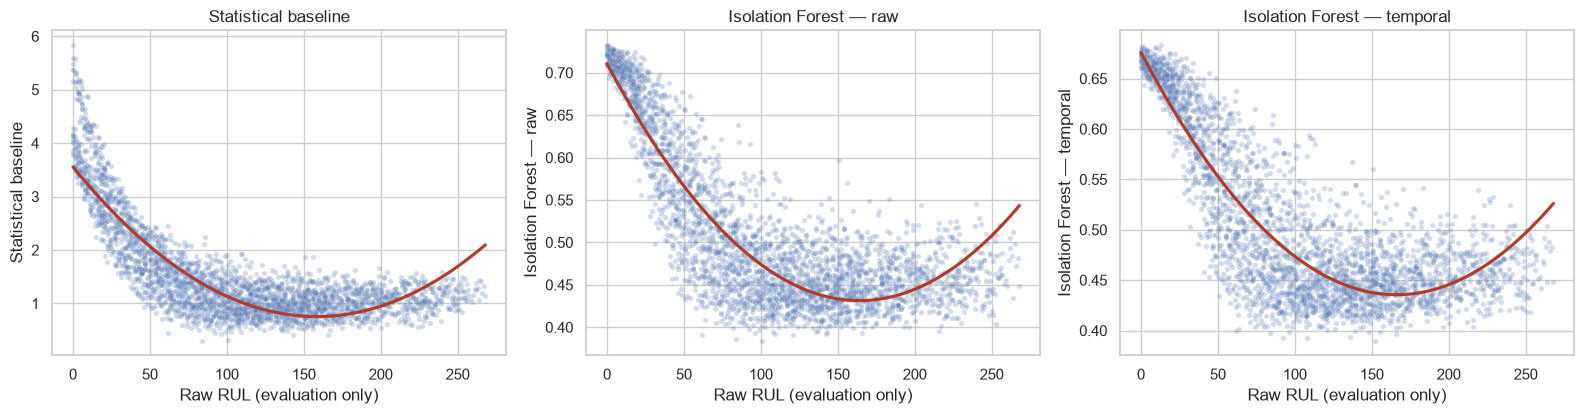

In [9]:
correlation_rows = []
for score in score_columns:
    rho, rho_p = spearmanr(heldout_df[score], heldout_df.raw_rul)
    r, r_p = pearsonr(heldout_df[score], heldout_df.raw_rul)
    correlation_rows.append({"model": score, "spearman_rho": rho, "spearman_p": rho_p, "pearson_r": r, "pearson_p": r_p})
correlations = pd.DataFrame(correlation_rows).set_index("model")
display(correlations.round(4))

sample_plot = heldout_df.sample(min(3000, len(heldout_df)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
for ax, score in zip(axes, score_columns):
    sns.scatterplot(data=sample_plot, x="raw_rul", y=score, alpha=.25, s=14, ax=ax)
    sns.regplot(data=sample_plot, x="raw_rul", y=score, scatter=False, order=2, ci=None, color="#b23a2b", ax=ax)
    ax.set_title(score); ax.set_xlabel("Raw RUL (evaluation only)")
plt.tight_layout(); plt.show()

## 10. Candidate Early-Warning Quantiles

The 95th, 97.5th, and 99th percentile thresholds are derived independently from each model's **training normal-reference scores only**. All candidates are reported neutrally; held-out lifecycle outcomes are not used to tune or select one. Because no true anomaly label exists, healthy-stage flags are called **early-stage alerts**, not false positives.

In [10]:
train_scores = {
    "Statistical baseline": baseline_train_score,
    "Isolation Forest — raw": if_raw_train_score,
    "Isolation Forest — temporal": if_temporal_train_score,
}
threshold_records, alert_records = [], []
for model, scores in train_scores.items():
    for q in QUANTILES:
        threshold = float(np.quantile(scores, q))
        threshold_records.append({"model": model, "quantile": q, "threshold": threshold, "source": "training normal only"})
        for stage in STAGE_ORDER:
            stage_scores = heldout_df.loc[heldout_df.lifecycle_stage == stage, model]
            alert_records.append({"model": model, "quantile": q, "lifecycle_stage": stage,
                                  "observations": len(stage_scores), "alert_rate_pct": 100 * (stage_scores > threshold).mean()})
threshold_table = pd.DataFrame(threshold_records)
alert_table = pd.DataFrame(alert_records)
display(threshold_table.round(4))
display(alert_table.pivot_table(index=["model", "quantile"], columns="lifecycle_stage", values="alert_rate_pct").round(2))
assert (threshold_table.source == "training normal only").all()

,model,quantile,threshold,source
0,Statistical baseline,0.950,1.4030,training normal only
1,Statistical baseline,0.975,1.4899,training normal only
2,Statistical baseline,0.990,1.6030,training normal only
3,Isolation Forest — raw,0.950,0.5037,training normal only
4,Isolation Forest — raw,0.975,0.5186,training normal only
5,Isolation Forest — raw,0.990,0.5359,training normal only
6,Isolation Forest — temporal,0.950,0.5007,training normal only
7,Isolation Forest — temporal,0.975,0.5129,training normal only
8,Isolation Forest — temporal,0.990,0.5273,training normal only


lifecycle_stage                       Critical late life  Degrading  \
model                       quantile                                  
Isolation Forest — raw      0.950                 100.00      23.54   
                            0.975                 100.00      15.85   
                            0.990                  99.84       9.92   
Isolation Forest — temporal 0.950                 100.00      26.77   
                            0.975                 100.00      20.31   
                            0.990                 100.00      15.00   
Statistical baseline        0.950                 100.00      24.69   
                            0.975                 100.00      17.85   
                            0.990                  99.84      11.92   

lifecycle_stage                       Healthy / early  Near failure  
model                       quantile                                 
Isolation Forest — raw      0.950                6.26         83.50  
                            0.975                2.71         78.00  
                            0.990                0.77         69.17  
Isolation Forest — temporal 0.950                5.10         83.17  
                            0.975                3.03         79.00  
                            0.990                1.16         72.67  
Statistical baseline        0.950                6.45         83.67  
                            0.975                2.77         78.50  
                            0.990                0.71         72.67

## 11. Representative Held-Out Engine Trajectories

Units are selected mechanically by held-out lifetime: shortest, closest to the held-out median, and longest. This avoids choosing visually convenient examples.

,selection,unit_id,lifetime
0,Shortest-lived,91,135
1,Median-lived,1,192
2,Longest-lived,5,269


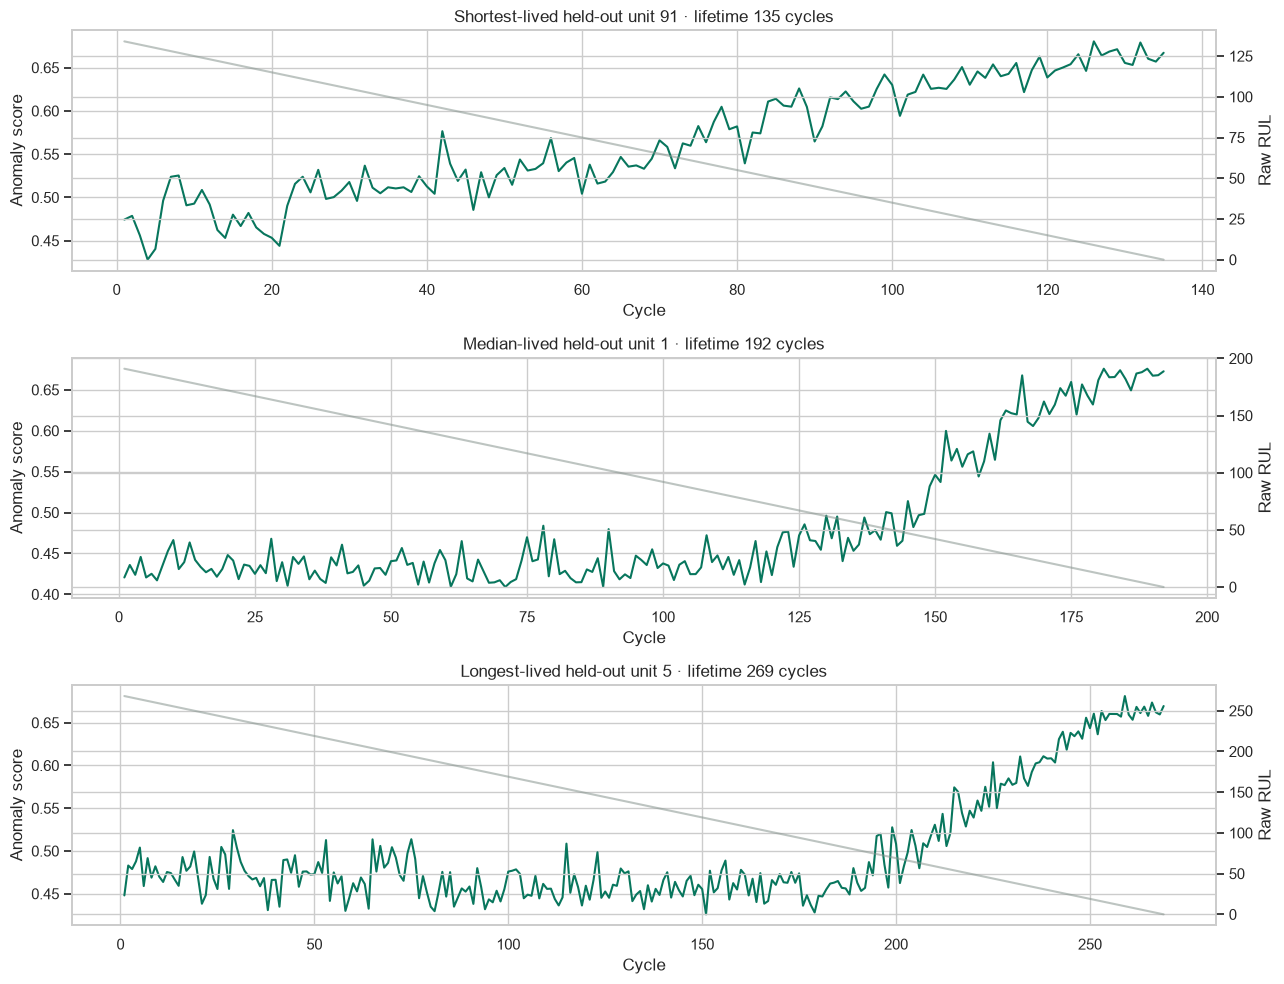

In [11]:
lifetimes = heldout_df.groupby("unit_id").cycle.max().sort_values()
short_unit = lifetimes.index[0]
median_life = lifetimes.median()
median_unit = (lifetimes - median_life).abs().idxmin()
long_unit = lifetimes.index[-1]
representatives = [("Shortest-lived", short_unit), ("Median-lived", median_unit), ("Longest-lived", long_unit)]
display(pd.DataFrame([{"selection": label, "unit_id": unit, "lifetime": int(lifetimes.loc[unit])} for label, unit in representatives]))

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=False)
for ax, (label, unit) in zip(axes, representatives):
    trajectory = heldout_df[heldout_df.unit_id == unit]
    ax.plot(trajectory.cycle, trajectory["Isolation Forest — temporal"], color="#08765d", label="Temporal anomaly score")
    ax2 = ax.twinx(); ax2.plot(trajectory.cycle, trajectory.raw_rul, color="#87958f", alpha=.55, label="Raw RUL (evaluation)")
    ax.set_title(f"{label} held-out unit {unit} · lifetime {lifetimes.loc[unit]} cycles")
    ax.set_ylabel("Anomaly score"); ax2.set_ylabel("Raw RUL"); ax.set_xlabel("Cycle")
plt.tight_layout(); plt.show()

## 12. Exploratory Sensor-Deviation Interpretation

Isolation Forest has no simple per-row explanation. As a limited diagnostic, the most anomalous held-out rows are examined using absolute standardized deviations from training-normal sensor means. These are not causal effects or formal feature importances.

In [12]:
top_positions = np.argsort(heldout_df["Isolation Forest — raw"].to_numpy())[-50:]
top_z = pd.DataFrame(np.abs(heldout_z[top_positions]), columns=SENSOR_FEATURES)
sensor_deviation_summary = top_z.mean().sort_values(ascending=False).rename("mean_absolute_z_top_50").to_frame()
display(sensor_deviation_summary.head(10).round(3))

top_rows = heldout_df.iloc[top_positions].copy()
top_rows["most_extreme_sensor"] = top_z.idxmax(axis=1).to_numpy()
top_rows["largest_absolute_z"] = top_z.max(axis=1).to_numpy()
display(top_rows[["unit_id", "cycle", "raw_rul", "lifecycle_stage", "Isolation Forest — raw", "most_extreme_sensor", "largest_absolute_z"]].sort_values("Isolation Forest — raw", ascending=False).head(10).round(3))

,mean_absolute_z_top_50
sensor_9,5.730
sensor_14,4.655
sensor_11,4.438
sensor_4,4.122
sensor_15,3.845
sensor_12,3.831
sensor_7,3.813
sensor_20,3.745
sensor_21,3.612
sensor_3,3.452


,unit_id,cycle,raw_rul,lifecycle_stage,Isolation Forest — raw,most_extreme_sensor,largest_absolute_z
7825,40,188,0,Critical late life,0.732,sensor_9,10.039
8794,45,158,0,Critical late life,0.732,sensor_4,5.937
6410,32,190,1,Critical late life,0.732,sensor_15,4.943
191,1,192,0,Critical late life,0.731,sensor_11,5.183
6407,32,187,4,Critical late life,0.729,sensor_4,4.920
7823,40,186,2,Critical late life,0.729,sensor_9,8.968
15749,78,227,4,Critical late life,0.728,sensor_20,5.107
7821,40,184,4,Critical late life,0.728,sensor_9,8.507
15750,78,228,3,Critical late life,0.728,sensor_9,4.938
8793,45,157,1,Critical late life,0.728,sensor_4,5.094


## 13. Model Comparison and Stability

Proxy metrics are summarized without fake accuracy or F1. Early/late separation and alert rates measure association with degradation, not validated anomaly detection. Unit-level Spearman variability provides a limited stability view.

In [13]:
comparison_rows = []
for model in score_columns:
    stage_medians = heldout_df.groupby("lifecycle_stage", observed=True)[model].median()
    unit_rhos = heldout_df.groupby("unit_id").apply(lambda g: spearmanr(g[model], g.raw_rul).statistic, include_groups=False)
    q975 = threshold_table.query("model == @model and quantile == 0.975").threshold.iloc[0]
    healthy_rate = 100 * (heldout_df.loc[heldout_df.lifecycle_stage == "Healthy / early", model] > q975).mean()
    critical_rate = 100 * (heldout_df.loc[heldout_df.lifecycle_stage == "Critical late life", model] > q975).mean()
    comparison_rows.append({
        "model": model,
        "spearman_vs_rul": correlations.loc[model, "spearman_rho"],
        "healthy_median": stage_medians["Healthy / early"],
        "critical_median": stage_medians["Critical late life"],
        "late_minus_early_median": stage_medians["Critical late life"] - stage_medians["Healthy / early"],
        "healthy_alert_rate_97.5_pct": healthy_rate,
        "critical_alert_rate_97.5_pct": critical_rate,
        "median_unit_spearman": unit_rhos.median(),
        "unit_spearman_iqr": unit_rhos.quantile(.75) - unit_rhos.quantile(.25),
    })
comparison = pd.DataFrame(comparison_rows).set_index("model")
display(comparison.round(4))

,spearman_vs_rul,healthy_median,critical_median,late_minus_early_median,healthy_alert_rate_97.5_pct,critical_alert_rate_97.5_pct,median_unit_spearman,unit_spearman_iqr
model,,,,,,,,
Statistical baseline,-0.6861,1.0130,3.2191,2.2062,2.7742,100.0,-0.8396,0.3036
Isolation Forest — raw,-0.7034,0.4492,0.6911,0.2418,2.7097,100.0,-0.7844,0.2370
Isolation Forest — temporal,-0.6946,0.4489,0.6525,0.2036,3.0323,100.0,-0.8227,0.3575


## 14. Exploratory 0–100 Score Representation

For research only, each score is mapped to its percentile within that model's training normal-reference distribution. This makes 0–100 an unusualness percentile—not a probability of failure or anomaly. The mapping is not frozen for production.

In [14]:
def reference_percentile_score(reference_scores, values):
    ordered = np.sort(np.asarray(reference_scores))
    return 100 * np.searchsorted(ordered, np.asarray(values), side="right") / len(ordered)

heldout_df["temporal_anomaly_percentile_0_100"] = reference_percentile_score(
    if_temporal_train_score, heldout_df["Isolation Forest — temporal"]
)
display(heldout_df["temporal_anomaly_percentile_0_100"].describe(percentiles=[.5, .9, .95, .99]).to_frame().T.round(2))
print("Interpretation: training-normal reference percentile, not probability.")

,count,mean,std,min,50%,90%,95%,99%,max
temporal_anomaly_percentile_0_100,4070.0,71.12,30.75,0.03,82.67,100.0,100.0,100.0,100.0


Interpretation: training-normal reference percentile, not probability.


## 15. Critical Leakage Safeguards

The assertions below make the notebook's methodological boundaries explicit.

In [15]:
all_predictors = set(SENSOR_FEATURES) | set(TEMPORAL_FEATURES)
assert not {"raw_rul", "RUL", "capped_rul", "final_lifetime", "unit_id", "cycle"}.intersection(all_predictors)
assert train_units.isdisjoint(heldout_units)
assert set(normal_train.unit_id).issubset(train_units)
assert state_scaler.n_samples_seen_ == len(normal_train)
assert temporal_scaler.n_samples_seen_ == len(normal_temporal)
assert (threshold_table.source == "training normal only").all()
assert TRAIN_PATH.name == "train_FD001.txt"  # no official test set or test RUL labels loaded
assert not any(Path("../models").glob("*anomaly*"))
print("PASS: RUL/failure labels are not predictors.")
print("PASS: held-out units fit neither scaler nor detector.")
print("PASS: thresholds use training-normal scores only.")
print("PASS: temporal features are unit-grouped and backward-looking.")
print("PASS: no official test labels were loaded and no anomaly artifact was serialized.")

PASS: RUL/failure labels are not predictors.
PASS: held-out units fit neither scaler nor detector.
PASS: thresholds use training-normal scores only.
PASS: temporal features are unit-grouped and backward-looking.
PASS: no official test labels were loaded and no anomaly artifact was serialized.


## 16. Methodological Limitations

- FD001 is simulated and contains one operating condition and one fault mode.
- “Normal” is defined retrospectively through an early-life RUL assumption, not externally verified healthy labels.
- There is no true anomaly ground truth; degradation and anomaly are related but not identical.
- Lifecycle association, correlation, and alert rates are proxy diagnostics rather than deployment metrics.
- Healthy-reference quantiles are development heuristics, not production alert thresholds.
- Temporal features may smooth noise while delaying abrupt changes; stability needs broader validation.
- A real industrial system needs validated healthy/fault operating data, operating-regime controls, sensor-quality checks, threshold validation, and drift monitoring.

## Anomaly Detection Baseline Conclusions

The normal reference uses 6,481 observations from all 80 development units with `raw_rul > 125`; 20 held-out units contribute 4,070 evaluation observations with zero unit overlap. Predictors contain 14 retained sensors. Operational settings, cycle, unit identity, RUL, and labels are excluded.

All three scores rise materially toward late life. Held-out Spearman correlations with raw RUL are −0.686 for standardized distance, −0.703 for raw-state Isolation Forest, and −0.695 for temporal Isolation Forest. At the training-normal 97.5th-percentile candidate, healthy-stage alert rates are 2.77%, 2.71%, and 3.03%, respectively, while every model flags 100% of critical-late-life observations. The raw-state Isolation Forest therefore provides the strongest overall correlation and slightly lower early-alert burden; the focused temporal features do not improve this baseline enough to retain automatically.

Mechanically selected short-, median-, and long-lived held-out trajectories show an overall late-life rise with engine-specific noise and occasional earlier spikes rather than perfectly monotonic degradation. Exploratory standardized deviations in the 50 highest raw-Isolation-Forest scores are largest for sensors 9, 14, 11, 4, and 15; these are descriptive deviations, not causal feature importance. Candidate 95%, 97.5%, and 99% policies remain neutral research heuristics derived exclusively from training-normal scores. No proxy proves anomaly validity.

**Verdict: B) Signal exists but methodology needs another research notebook first.**

Classical anomaly scoring is useful enough to continue, but a production design would be premature without sensitivity analysis for the normal-reference definition, repeated unit splits, threshold stability, operating-regime robustness, and more formal temporal evaluation.

**Recommended next step:** `notebooks/12_anomaly_detection_refinement.ipynb`—do not create it yet.